# TP1 – Équation de la Chaleur 1D 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Paramètres de Simulation

In [2]:
# --- Parametres physiques ---
L = 1.0 # Longueur de la barre (m)
alpha = 1.11e-4 # Diffusivite thermique du cuivre (m^2/s)
T_gauche = 100.0 # Temperature a x=0 ( degC )
T_droite = 0.0 # Temperature a x=L ( degC )
T_init = 0.0 # Temperature initiale uniforme ( degC )

# --- Parametres numeriques ---
N = 20 # Nombre d’intervalles spatiaux
dx = L / N # Pas spatial (m)
r = 0.4 # Nombre de Fourier discret ( choisir r <= 0.5)
dt = (r * dx**2) / alpha # Pas de temps : a calculer depuis r, dx et alpha
t_fin = 3000 # Duree de simulation (s)
nt = int ( t_fin / dt )

print ( f"dx = {dx :.4f} m")
print ( f"dt = {dt :.4f} s")
print ( f"r = {r:.4f} ( doit etre <= 0.5) ")
print ( f" Nombre de pas de temps : {nt}")

dx = 0.0500 m
dt = 9.0090 s
r = 0.4000 ( doit etre <= 0.5) 
 Nombre de pas de temps : 332


## Initialisation du Domaine


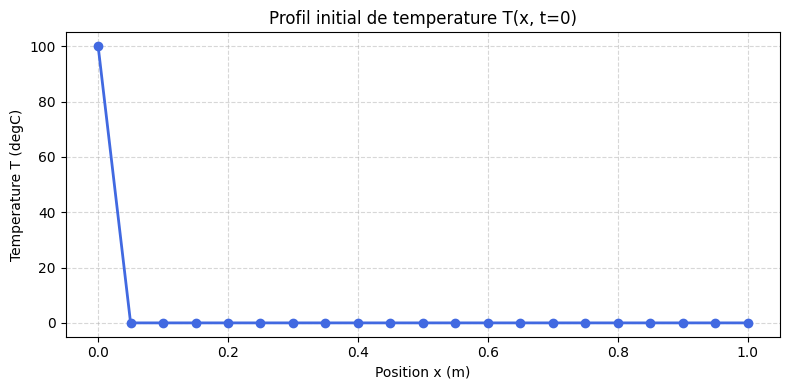

In [3]:
# --- Creation de la grille spatiale ---
x = np.linspace(L,0,N+1)  # N+1 points de x=0 a x=L

# --- Condition initiale ---
T = np.ones(N + 1) * T_init

# --- Application des conditions aux limites ---
T[0] = T_droite
T[-1] =T_gauche

# --- Visualisation du profil initial ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, T, 'o-', color='royalblue', linewidth=2, markersize=6)
ax.set_xlabel('Position x (m)')
ax.set_ylabel('Temperature T (degC)')
ax.set_title("Profil initial de temperature T(x, t=0)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


## Boucle Temporelle Principale

In [4]:
# --- Stockage periodique de la solution ---
save_frac = 10
save_step = max(1, nt // save_frac)
T_save = [T.copy()]
t_save = [0.0]

T_new = T.copy()

for n in range(1, nt+1):
    # Mise a jour des noeuds interieurs (i = 1 a N-1)
    for i in range(1, N):
        T_new[i] = T_new[i] + r*(T_new[i+1] - 2*T_new[i] + T_new[i-1])

    T = T_new.copy()  # pourquoi " copy " ?

    # Sauvegarde periodique
    if n % save_step == 0:
        T_save.append(T.copy())
        t_save.append(n*dt)
        
T_save = np . array ( T_save )
print ( f" Nombre de profils sauvegardes : {len ( T_save )}")


 Nombre de profils sauvegardes : 11


# Analyse d’un cas minimaliste

In [5]:
"""
import numpy as np

T = np . array ([1.0 , 2.0 , 3.0])
T_save = []

T_save . append ( T ) # stocke la référence
print ( T_save [0]) # [1. 2. 3.]

T [0] = 999 # on modifie T
print ( T_save [0]) # [999. 2. 3.] modifié aussi !

T_save . append ( T . copy () ) # stocke une copie indépendante
T [0] = 999
print ( T_save [0]) # [1. 2. 3.] inchangé
"""

'\nimport numpy as np\n\nT = np . array ([1.0 , 2.0 , 3.0])\nT_save = []\n\nT_save . append ( T ) # stocke la référence\nprint ( T_save [0]) # [1. 2. 3.]\n\nT [0] = 999 # on modifie T\nprint ( T_save [0]) # [999. 2. 3.] modifié aussi !\n\nT_save . append ( T . copy () ) # stocke une copie indépendante\nT [0] = 999\nprint ( T_save [0]) # [1. 2. 3.] inchangé\n'

## Visualisation des Résultats

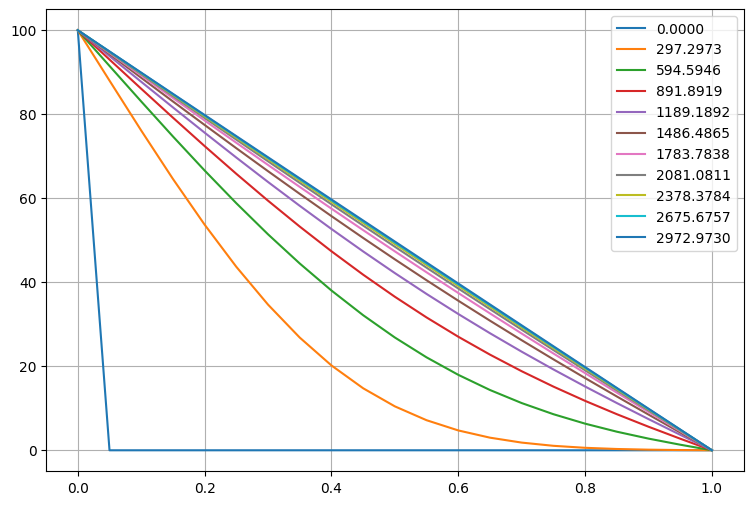

In [6]:
fig , ax = plt . subplots ( figsize =(9 , 6) )

colors = cm . plasma ( np . linspace (0 , 1 , len ( T_save ) ) )
for i in range(len(T_save)):
    ax.plot(x,T_save[i],label = f"{t_save[i]:.4f}")
    
plt.grid()
plt.legend()
plt.show()

## Encapsulation dans une fonction


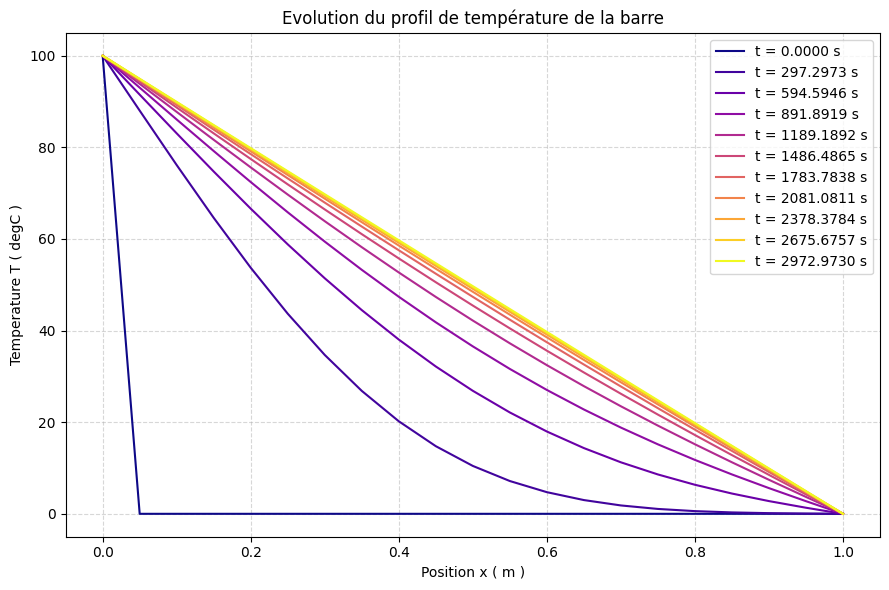

In [7]:
def simulation_chaleur (L , alpha , N , r , t_fin , T_gauche ,T_droite , T_init , save_frac =10) :
    """
    Résout l’équation de la chaleur 1D par schéma Euler
    explicite .
     Paramètres :
     ------------
     L : longueur de la barre (m)
     alpha : diffusivité thermique (mš/s)
     N : nombre d’intervalles spatiaux
     r : nombre de Fourier discret (r <= 0.5 pour la
    stabilité )
     t_fin : durée totale de simulation (s)
     T_gauche : température à x=0 (řC)
     T_droite : température à x=L (řC)
     T_init : température initiale uniforme (řC)
     Retourne :
     x, t_save , T_save
     """

    dx = L / N
    r = 0.4 # Nombre de Fourier discret ( choisir r <= 0.5)
    dt = (r * dx**2) / alpha # Pas de temps : a calculer depuis r, dx et alpha
    nt = int ( t_fin / dt )
    x = np.linspace(L,0,N+1)  # N+1 points de x=0 a x=L

    # --- Condition initiale ---
    T = np.ones(N + 1) * T_init

    # --- Application des conditions aux limites ---
    T[0] = T_droite
    T[-1] =T_gauche
            
    save_step = max(1, nt // save_frac)
    T_save = [T.copy()]
    t_save = [0.0]
    T_new = T.copy()
    for n in range(1, nt+1):
        # Mise a jour des noeuds interieurs (i = 1 a N-1)
        for i in range(1, N):
            T_new[i] = T_new[i] + r*(T_new[i+1] - 2*T_new[i] + T_new[i-1])

        T = T_new.copy()  # pourquoi " copy " ?

        # Sauvegarde periodique
        if n % save_step == 0:
            T_save.append(T.copy())
            t_save.append(n*dt)
            
    T_save = np . array ( T_save )

    return x , np . array ( t_save ) , np . array ( T_save )
  
def Tracer_T_x(x, t, T):
    fig , ax = plt.subplots(figsize = (9 , 6) )
    colors = cm.plasma(np.linspace(0 , 1 , len(T_save)))

    for k, (T_k, t_k) in enumerate(zip(T_save, t_save)):
        ax.plot (x , T_k , color=colors[k], label=f"t = {t_k:.4f} s")

    ax.set_xlabel (  "Position x ( m )" )
    ax.set_ylabel ( "Temperature T ( degC )" )
    ax.legend(loc='upper right')
    ax.set_title ( "Evolution du profil de température de la barre" )
    ax.grid (True, linestyle = "--"  , alpha = 0.5)
    plt.tight_layout()
    plt.show()
    
x,t_save,T_save = simulation_chaleur(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)

Tracer_T_x(x,t_save,T_save)

# Partie 3 – Optimisation avec NumPy

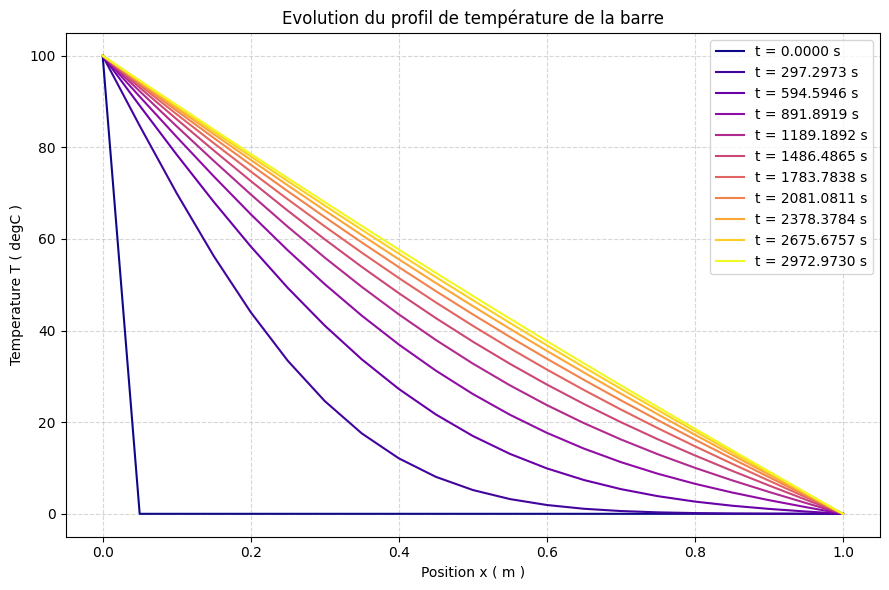

In [8]:
def simulation_chaleur_vect(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init, save_frac=10):
    """
    Resout l'equation de la chaleur 1D par schema FTCS
    (version vectorisee NumPy).

    Parametres
    ----------
    L : longueur de la barre (m)
    alpha : diffusivite thermique (m^2/s)
    N : nombre d'intervalles spatiaux
    r : nombre de Fourier discret (r <= 0.5)
    t_fin : duree totale de simulation (s)
    T_gauche : temperature a x=0 (degC)
    T_droite : temperature a x=L (degC)
    T_init : temperature initiale uniforme (degC)
    save_frac : fraction de pas de temps a sauvegarder

    Retourne
    --------
    x, t_save, T_save
    """
    dx = L / N
    dt = r * dx**2 / alpha
    nt = int(t_fin / dt)

    x = np.linspace(0, L, N+1)
    T = np.ones(N+1) * T_init
    T[0] = T_gauche
    T[-1] = T_droite

    save_every = max(1, nt // save_frac)
    T_save, t_save = [T.copy()], [0.0]

    for n in range(nt):
        # Version vectorisee : une seule ligne !
        T[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])
        # T[0] et T[-1] ne sont pas modifies (CL preservees)

        if (n + 1) % save_every == 0:
            T_save.append(T.copy())
            t_save.append((n + 1) * dt)

    return x, np.array(t_save), np.array(T_save)

x,t_save,T_save = simulation_chaleur_vect(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)

Tracer_T_x(x,t_save,T_save)

## Comparaison des Temps de Calcul


In [9]:
import time
"""
# --- Version avec boucle ( Partie 1) ---
debut = time . time ()
x,t_save,T_save = simulation_chaleur(L, alpha, 400, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)

# ... Appel à la fonction non véctorisée ici ...
fin = time . time ()

print ( f" Temps boucle for : {fin - debut } s")

# --- Version vectorisee ---
debut = time . time ()

x,t_save,T_save = simulation_chaleur_vect(L, alpha, 400, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)

# ... Appel à la fonction véctorisée ici ...
fin = time . time ()

print ( f" Temps vectorise : {fin - debut  } s")"""

'\n# --- Version avec boucle ( Partie 1) ---\ndebut = time . time ()\nx,t_save,T_save = simulation_chaleur(L, alpha, 400, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)\n\n# ... Appel à la fonction non véctorisée ici ...\nfin = time . time ()\n\nprint ( f" Temps boucle for : {fin - debut } s")\n\n# --- Version vectorisee ---\ndebut = time . time ()\n\nx,t_save,T_save = simulation_chaleur_vect(L, alpha, 400, r, t_fin, T_gauche, T_droite, T_init, save_frac=10)\n\n# ... Appel à la fonction véctorisée ici ...\nfin = time . time ()\n\nprint ( f" Temps vectorise : {fin - debut  } s")'

#  Partie 4 – Analyse de la Stabilité Numérique

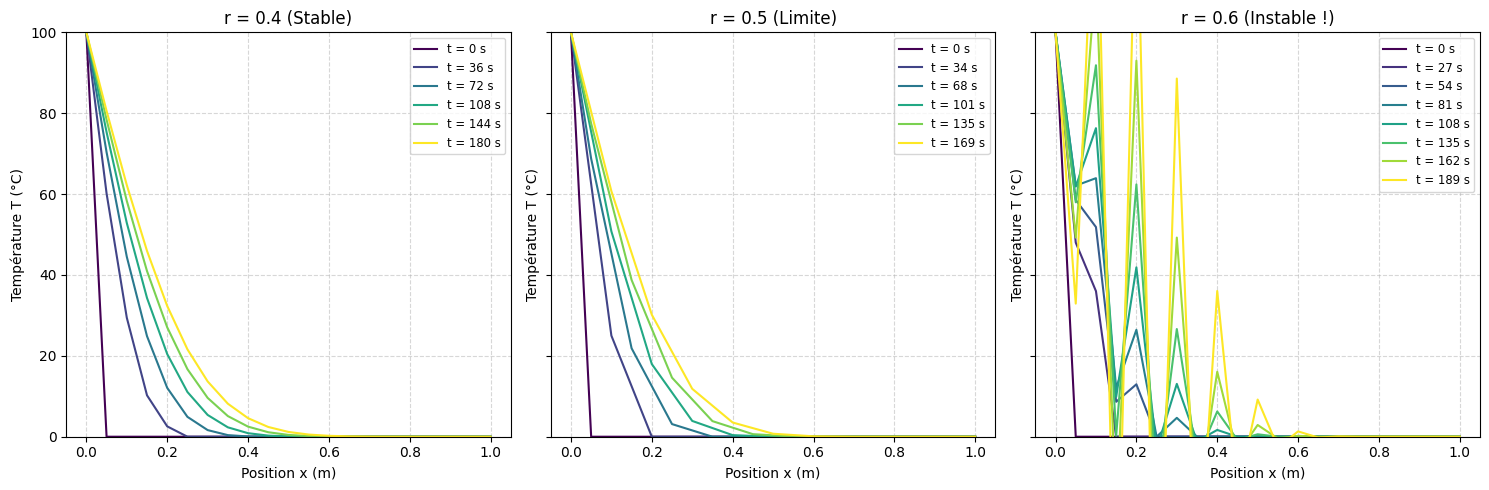

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

r_values = [0.4, 0.5, 0.6]
titres = ['r = 0.4 (Stable)', 'r = 0.5 (Limite)', 'r = 0.6 (Instable !)']



for ax, r_val, titre in zip(axes, r_values, titres):
    x_r, t_save_r, T_save_r = simulation_chaleur_vect(1, 1.11e-4, 20, r_val, 200, 100, 0, 0, save_frac=5)
    
    colors_r = cm.viridis(np.linspace(0, 1, len(T_save_r)))

    for k, (T_k, t_k) in enumerate(zip(T_save_r, t_save_r)):
        ax.plot(x_r, T_k, color=colors_r[k], label=f"t = {t_k:.0f} s")

    ax.set_title(titre)
    ax.set_xlabel('Position x (m)')
    ax.set_ylabel('Température T (°C)')
    
    if r_val > 0.5 :
        ax.set_ylim(0,100)
    else :
        ax.set_ylim(-200,200)

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()